#### Child Malnutrition Patterns and Inequality in East Africa. In this notebook the plan is to explore child nutrition patterns using DHS KR child file for Ethiopia, Kenya, Tanzania and Uganda. The main focus is on height-for-age(HAZ) and stunting across time and across income groups. We are also looking to connect these patterns to climate context later in the project.

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [166]:
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]

#### In this section I load all of the cleaned KR child files I made earlier.Each file represents one DHS survey year for one of the four countries.I add two small labels so each row knows which country it belongs to and survey year it comes from. After that, I stack everything together into one big table called child_data.This is the starting point for the rest of the analysis since all summariesof stunting, HAZ, inequality, and trends come from this combined dataset.

In [168]:
child_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    cols = df.columns
    
    # we only keep files that actually have HAZ and interview year
    if ("height for age SD per WHO" in cols) and ("interview year" in cols):
        # keep only the columns we need
        small = df[["height for age SD per WHO", "interview year"]].copy()
        
        # simple country name from the file name (first part before "_")
        country_name = fname.split("_")[0]
        small["country"] = country_name
        
        # rename so the column names are shorter to type later
        small = small.rename(columns={
            "height for age SD per WHO": "haz",
            "interview year": "survey_year",
        })
        
        child_list.append(small)

# put everything into one table
child_data = pd.concat(child_list, ignore_index=True)

child_data.head()


,haz,survey_year,country
0,-226.0,2003,Ethiopia
1,-379.0,2003,Ethiopia
2,-301.0,2003,Ethiopia
3,-300.0,2003,Ethiopia
4,-83.0,2003,Ethiopia


#### Clean HAZ values and define stunting. Here we drop rows where the height-for-age z score (HAZ) is missing because we cannot classify those children. A child is considered stunted if their HAZ value is less than minus two, which is the standard WHO(World Health Organization) cut-off. We create a new column called is_stunted that is True for stunted children. This makes it easier to summarize stunting by country, year, or wealth group.group.


In [170]:
# drop missing HAZ
child_data = child_data.dropna(subset=["haz"])

# stunting flag: True if HAZ < -2
child_data["is_stunted"] = child_data["haz"] < -2

child_data[["country", "survey_year", "haz", "is_stunted"]].head()


,country,survey_year,haz,is_stunted
0,Ethiopia,2003,-226.0,True
1,Ethiopia,2003,-379.0,True
2,Ethiopia,2003,-301.0,True
3,Ethiopia,2003,-300.0,True
4,Ethiopia,2003,-83.0,True


#### Creating a summary table for trends

Here we clean the HAZ values, create a simple stunting flag, and then group the data by country and survey year. For each country year pair we calculate:

- the mean HAZ
- the share of children who are stunted
- the number of children in the survey

We also turn the stunting share into a percent so it is easier to read. This summary table feeds into the line plot that shows how stunting changes over time in each country.


In [172]:
# drop missing HAZ and create stunting flag
children_all = child_data.dropna(subset=["haz"]).copy()
children_all["is_stunted"] = children_all["haz"] < -2

# summary by country and survey year
summary = (
    children_all
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)

# turn share into percent
summary["stunting_percent"] = summary["stunting_rate"] * 100

summary.head()

# for the trend plot we just copy the columns we need
stunting_trend = summary[["country", "survey_year", "stunting_percent", "n_children"]].copy()
stunting_trend.head()


,country,survey_year,stunting_percent,n_children
0,Ethiopia,2003,76.202290,10480
1,Ethiopia,2008,78.689986,8977
2,Ethiopia,2011,82.910652,5126
3,Kenya,2008,73.202089,2489
4,Kenya,2009,76.707764,3001


### Stunting trends over time
In this figure we plot the percent of children who are stunted in each survey year for the four countries.  
The x axis shows the survey year and the y axis shows the percent of children with HAZ below 2. Each line is one country. This lets us see whether stunting has been going down, staying flat, or getting worse for that country. The points do not cover every single year because DHS surveys are only done in certain years, not every year.

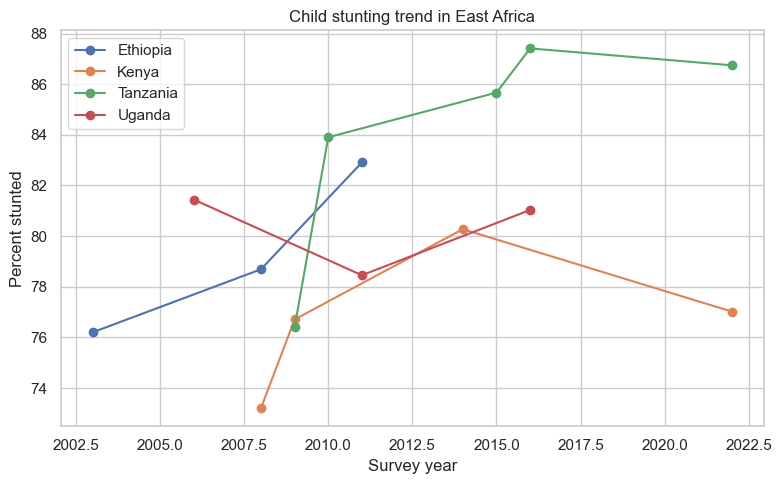

In [174]:
plt.figure(figsize=(8, 5))
for c in sorted(stunting_trend["country"].unique()):
    sub= stunting_trend[stunting_trend["country"] == c]
    plt.plot(sub["survey_year"], sub["stunting_percent"], marker ="o", label=c)

plt.xlabel("Survey year")
plt.ylabel("Percent stunted")
plt.title("Child stunting trend in East Africa")
plt.legend()
plt.tight_layout()
plt.show()


#### Visualizing stunting trends over time. Here I plot the percent of children who are stunted in each survey for each country. This helps me see if things have improved or gotten worse over the years. If the lines slope downward, that means stunting is decreasing.


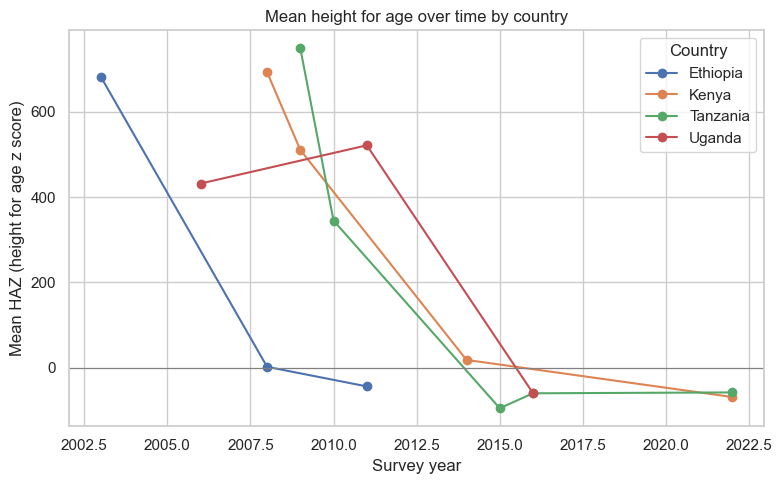

In [176]:
plt.figure(figsize=(8, 5))

countries = summary["country"].unique()

for country in countries:
    sub = summary[summary["country"] == country]
    plt.plot(sub["survey_year"], sub["mean_haz"], marker="o", label=country)

plt.axhline(0, color="gray", linewidth=0.8)  # zero line for reference

plt.xlabel("Survey year")
plt.ylabel("Mean HAZ (height for age z score)")
plt.title("Mean height for age over time by country")
plt.legend(title="Country")
plt.tight_layout()
plt.show()



### Change in stunting between the first and last DHS survey

Here we collapse the trend into just two points for each country. For every country we take the first DHS survey in our data and the last DHS survey and plot the percent of children who are stunted in those two years.Each line shows how stunting moved between the first and last survey for that country. If the line slopes down, stunting went down. If it is flat or slopes up, there was little progress or stunting got worse. 

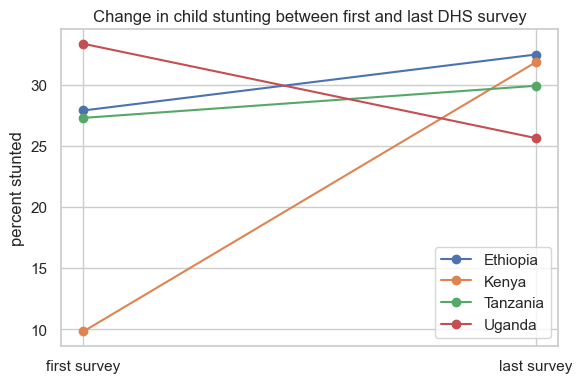

In [178]:
# simple before and after plot for each country
plt.figure(figsize=(6, 4))

for idx, row in change.iterrows():
    plt.plot(
        [0, 1],
        [row["stunting_first"], row["stunting_last"]],
        marker="o",
        label=row["country"],
    )

plt.xticks([0, 1], ["first survey", "last survey"])
plt.ylabel("percent stunted")
plt.title("Change in child stunting between first and last DHS survey")
plt.legend()
plt.tight_layout()
plt.show()



#### Next we look at the percent of children who are stunted over time.This is easier to interpret because it shows something like “X percent of children are stunted in this country and year” instead of raw z scores.  Here we make a bar chart.For each country we plot the percent of children who are stunted in each survey year. This makes it easier to see which years are higher or lower and how the pattern differs across Ethiopia, Kenya, Tanzania, and Uganda.



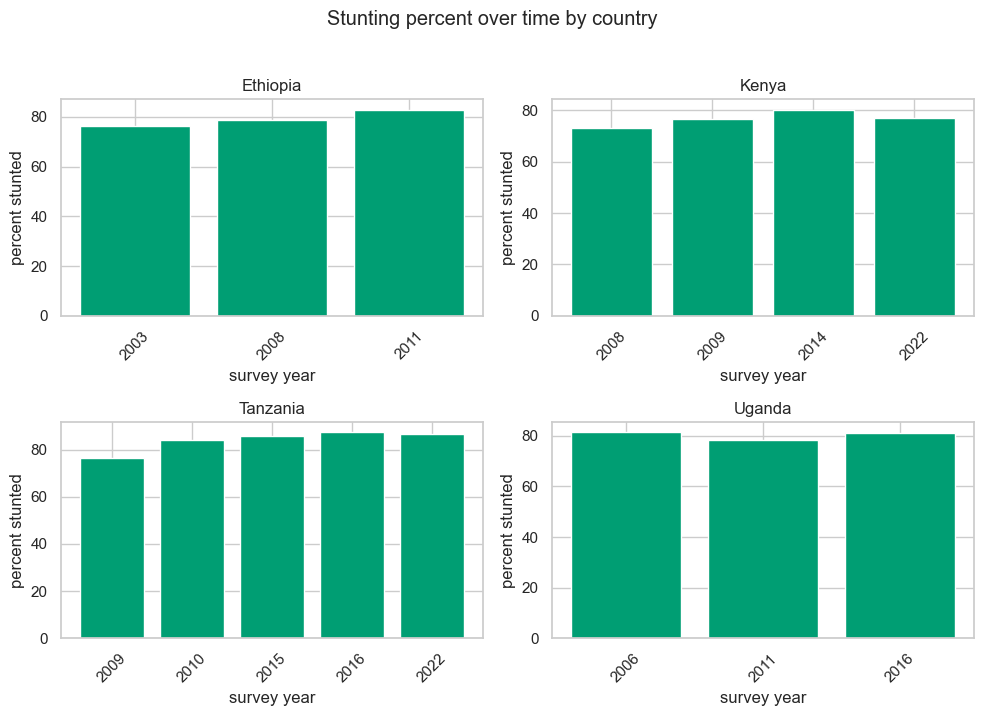

In [180]:
# bar chart of stunting over time, one small plot per country

countries = summary["country"].unique()

plt.figure(figsize=(10, 7))

for i, c in enumerate(countries):
    plt.subplot(2, 2, i + 1)
    
    # keep rows for this country and sort by year
    sub = summary[summary["country"] == c].copy()
    sub = sub.sort_values("survey_year")
    
    x_vals = sub["survey_year"].astype(str)
    y_vals = sub["stunting_percent"]
    
    # bright colorblind safe color

    plt.bar(x_vals, y_vals, color="#009E73")
    
    plt.title(c)
    plt.xlabel("survey year")
    plt.ylabel("percent stunted")
    plt.xticks(rotation=45)

plt.suptitle("Stunting percent over time by country", y=1.02)
plt.tight_layout()
plt.show()



#### We flagged children as stunted when their height-for-age z score (HAZ) was below -2. To simplify long-term analysis, survey years were grouped into decades.  For each country and decade, we calculated the number of children observed and the average stunting rate. The stunting rate was converted into a percentage to make results easier to interpret The next step is creating a heatmap, showing how stunting has shifted across countries over time.  This visualization highlights both regional differences and long-term progress in reducing child malnutrition.  


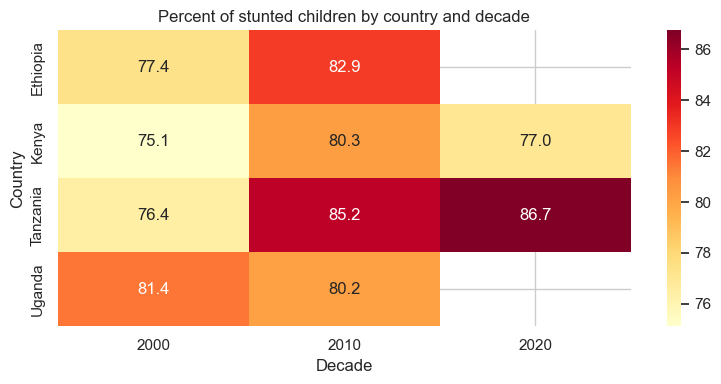

In [182]:
# use the cleaned child level table to look by decade
# we only keep the columns we need
children_all = child_data[["country", "survey_year", "haz"]].dropna().copy()

# stunting flag
children_all["is_stunted"] = children_all["haz"] < -2

# simple decade variable, for example 1992 -> 1990
def make_decade(y):
    return int(y // 10) * 10

children_all["decade"] = children_all["survey_year"].apply(make_decade)

# group by country and decade
stunting_decade = (
    children_all
    .groupby(["country", "decade"])
    .agg(
        n_children=("haz", "size"),
        stunting_rate=("is_stunted", "mean"),
    )
    .reset_index()
)

# convert to percent
stunting_decade["stunting_percent"] = stunting_decade["stunting_rate"] * 100

# reshape for heatmap
heat_table = stunting_decade.pivot(
    index="country",
    columns="decade",
    values="stunting_percent",
)

plt.figure(figsize=(8, 4))
sns.heatmap(heat_table, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Percent of stunted children by country and decade")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [183]:
# dropping rows where HAZ is missing just to be safe
child_data = child_data.dropna(subset=["haz"]).copy()

# keeping only HAZ in a normal range
child_data = child_data[child_data["haz"].between(-6, 6)].copy()

# redo the stunting flag
child_data["is_stunted"] = child_data["haz"] < -2

summary = (
    child_data
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)
summary["stunting_percent"] = summary["stunting_rate"] * 100



### Child HAZ in the first and most recent DHS survey
Here we pull out only the first and the most recent DHS survey for each country.  For every child in those two surveys I keep the HAZ score, the country, and the survey year, and add a simple label that says whether the observation comes from the first survey or the last survey. This `first_last` table is what I use to draw the density plots that compare the full HAZ distribution between the first and most recent survey in each country.


In [185]:
# build a child level table with only the first and last survey for each country
first_last_rows = []

for row in survey_years.itertuples():
    country = row.country
    first_year = row.min
    last_year = row.max

    # first survey for this country
    df_first = (
        child_data[
            (child_data["country"] == country)
            & (child_data["survey_year"] == first_year)
        ][["haz", "country", "survey_year"]]
        .copy()
    )
    df_first["timepoint"] = "first survey"

    # most recent survey
    df_last = (
        child_data[
            (child_data["country"] == country)
            & (child_data["survey_year"] == last_year)
        ][["haz", "country", "survey_year"]]
        .copy()
    )
    df_last["timepoint"] = "last survey"

    first_last_rows.append(df_first)
    first_last_rows.append(df_last)

first_last = pd.concat(first_last_rows, ignore_index=True)
first_last.head()



,haz,country,survey_year,timepoint
0,-5.0,Ethiopia,2003,first survey
1,4.0,Ethiopia,2003,first survey
2,0.0,Ethiopia,2003,first survey
3,-5.0,Ethiopia,2003,first survey
4,5.0,Ethiopia,2003,first survey


### Comparing the full HAZ distribution over time
In this step I plot the full distribution of child height for age z scores (HAZ) for the first and most recent DHS survey in each country. I use density plots instead of simple averages so we can see the whole shape of the distribution, not just one summary number. Each subplot shows one country. The blue curve is the first DHS survey and the orange curve is the most recent survey. If the orange curve moves closer to zero and becomes less spread out, that suggests fewer children are severely stunted and overall height for age has improved over time.

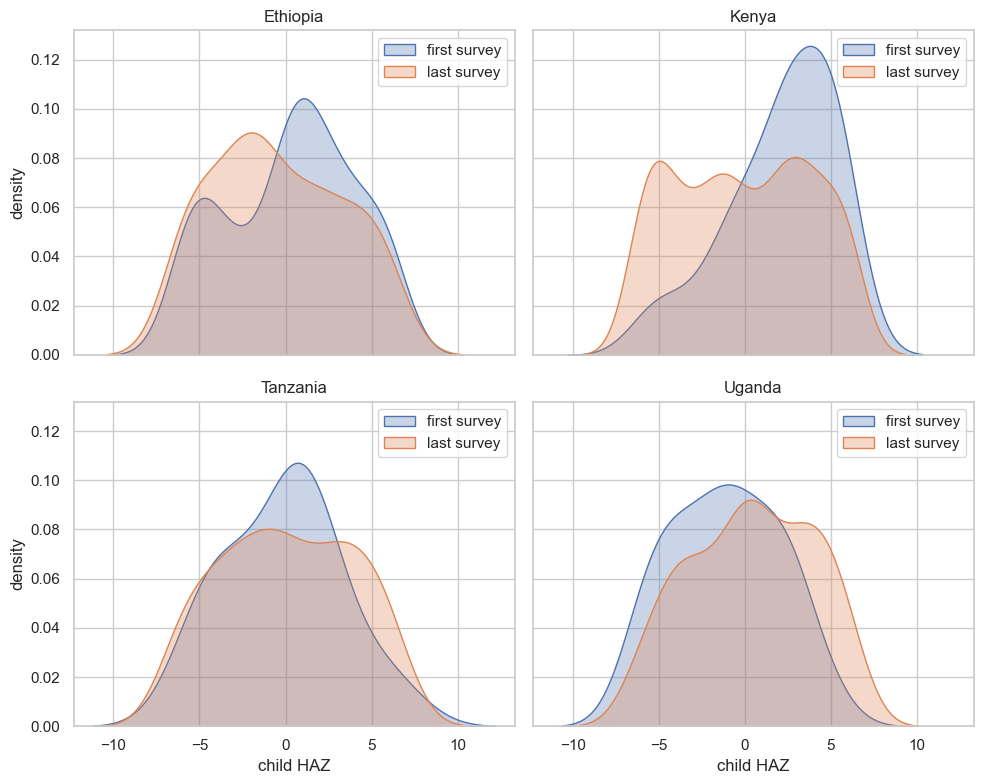

In [187]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

countries = sorted(first_last["country"].unique())

for i, country in enumerate(countries):
    ax = axes[i]
    sub = first_last[first_last["country"] == country]
    
    for t in ["first survey", "last survey"]:
        tmp = sub[sub["timepoint"] == t]
        sns.kdeplot(
            data=tmp,
            x="haz",
            fill=True,
            alpha=0.3,
            ax=ax,
            label=t
        )
    
    ax.set_title(country)
    ax.set_xlabel("child HAZ")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()


### Comparing the first and most recent DHS survey for each country

Here I made a simple before vs after plot to show how stunting changed between
the earliest and the latest DHS survey we have for each country.

Each country has two dots:
* one for the first survey stunting percent
* one for the most recent survey stunting percent

The line between the dots is just to show direction (up or down) without making
a full slope chart. This gives a quick visual summary of long term progress.


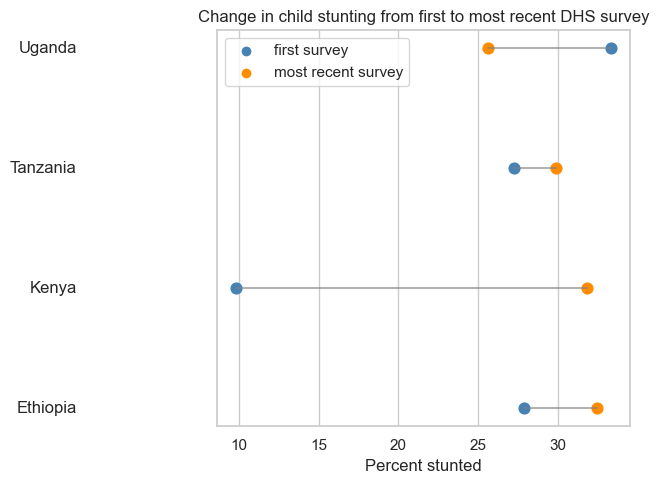

In [189]:
plt.figure(figsize=(7, 5))

# Put countries on y axis for a clean “paired dots” look
y_positions = range(len(change))

for i, row in enumerate(change.itertuples()):
    # two x-values: first survey stunting and last survey stunting
    x_vals = [row.stunting_first, row.stunting_last]
    
    # y position is constant for the pair
    y = [i, i]
    
    # line connecting before/after
    plt.plot(x_vals, y, color="gray", alpha=0.6)
    
    # dots for first and last
    plt.scatter(x_vals[0], y[0], color="steelblue", s=60)
    plt.scatter(x_vals[1], y[1], color="darkorange", s=60)
    
    # label the country on the y-axis
    plt.text(-0.2, i, row.country, va="center", ha="right")

# y-axis as country names
plt.yticks([])  # actual labels are drawn manually above

plt.xlabel("Percent stunted")
plt.title("Change in child stunting from first to most recent DHS survey")

# little legend
plt.scatter([], [], color="steelblue", label="first survey")
plt.scatter([], [], color="darkorange", label="most recent survey")
plt.legend()

plt.tight_layout()
plt.show()
